# ICU Patient Deterioration Prediction

## Comparative Analysis of Machine Learning and Deep Learning Models

### Models Used
- Decision Tree
- Random Forest
- Support Vector Machine (SVM)
- XGBoost
- LSTM

### Dataset
Hospital Deterioration Hourly Panel Dataset

### Objective
Develop and compare multiple Machine Learning and Deep Learning models to predict ICU patient deterioration within the next 12 hours and identify the best-performing model.

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Machine Learning Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# XGBoost
from xgboost import XGBClassifier

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("=" * 60)
print("ICU Patient Deterioration Prediction Project")
print("=" * 60)
print("All required libraries imported successfully!")

ICU Patient Deterioration Prediction Project
All required libraries imported successfully!


In [3]:
# Load the dataset
df = pd.read_csv("hospital_deterioration_hourly_panel.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
# Display the first five records

df.head()

,patient_id,hour_from_admission,heart_rate,respiratory_rate,spo2_pct,temperature_c,systolic_bp,diastolic_bp,oxygen_device,oxygen_flow,...,age,gender,comorbidity_index,admission_type,baseline_risk_score,los_hours,deterioration_event,deterioration_within_12h_from_admission,deterioration_hour,deterioration_next_12h
0,1,0,68.58,14.47,96.52,37.18,108.94,78.43,none,0.0,...,24,M,2,Elective,0.2173,17,0,0,-1,0
1,1,1,67.03,13.87,94.94,37.25,111.73,79.14,none,0.0,...,24,M,2,Elective,0.2173,17,0,0,-1,0
2,1,2,69.05,14.63,94.45,37.29,111.48,78.86,none,0.0,...,24,M,2,Elective,0.2173,17,0,0,-1,0
3,1,3,69.07,14.42,95.16,37.27,110.68,76.79,none,0.0,...,24,M,2,Elective,0.2173,17,0,0,-1,0
4,1,4,73.35,15.62,95.83,37.21,110.38,75.47,none,0.0,...,24,M,2,Elective,0.2173,17,0,0,-1,0


In [5]:
# Display the last five records

df.tail()

,patient_id,hour_from_admission,heart_rate,respiratory_rate,spo2_pct,temperature_c,systolic_bp,diastolic_bp,oxygen_device,oxygen_flow,...,age,gender,comorbidity_index,admission_type,baseline_risk_score,los_hours,deterioration_event,deterioration_within_12h_from_admission,deterioration_hour,deterioration_next_12h
417861,10000,24,89.82,20.65,95.46,36.43,122.05,70.56,none,0.0,...,62,F,1,ED,0.2059,29,0,0,-1,0
417862,10000,25,92.38,20.80,95.30,36.46,124.08,72.08,none,0.0,...,62,F,1,ED,0.2059,29,0,0,-1,0
417863,10000,26,94.65,21.43,94.39,36.43,123.59,71.41,none,0.0,...,62,F,1,ED,0.2059,29,0,0,-1,0
417864,10000,27,95.72,21.23,94.90,36.46,121.17,70.60,none,0.0,...,62,F,1,ED,0.2059,29,0,0,-1,0
417865,10000,28,93.46,20.76,94.83,36.42,119.53,71.02,none,0.0,...,62,F,1,ED,0.2059,29,0,0,-1,0


In [6]:
# Check number of rows and columns

print("Dataset Shape :", df.shape)

Dataset Shape : (417866, 28)


In [7]:
# Display all column names

print(df.columns.tolist())

['patient_id', 'hour_from_admission', 'heart_rate', 'respiratory_rate', 'spo2_pct', 'temperature_c', 'systolic_bp', 'diastolic_bp', 'oxygen_device', 'oxygen_flow', 'mobility_score', 'nurse_alert', 'wbc_count', 'lactate', 'creatinine', 'crp_level', 'hemoglobin', 'sepsis_risk_score', 'age', 'gender', 'comorbidity_index', 'admission_type', 'baseline_risk_score', 'los_hours', 'deterioration_event', 'deterioration_within_12h_from_admission', 'deterioration_hour', 'deterioration_next_12h']


In [8]:
# Display datatype of each column

df.dtypes

patient_id                                   int64
hour_from_admission                          int64
heart_rate                                 float64
respiratory_rate                           float64
spo2_pct                                   float64
temperature_c                              float64
systolic_bp                                float64
diastolic_bp                               float64
oxygen_device                                  str
oxygen_flow                                float64
mobility_score                               int64
nurse_alert                                  int64
wbc_count                                  float64
lactate                                    float64
creatinine                                 float64
crp_level                                  float64
hemoglobin                                 float64
sepsis_risk_score                          float64
age                                          int64
gender                         

In [9]:
# Display complete dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 417866 entries, 0 to 417865
Data columns (total 28 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   patient_id                               417866 non-null  int64  
 1   hour_from_admission                      417866 non-null  int64  
 2   heart_rate                               417866 non-null  float64
 3   respiratory_rate                         417866 non-null  float64
 4   spo2_pct                                 417866 non-null  float64
 5   temperature_c                            417866 non-null  float64
 6   systolic_bp                              417866 non-null  float64
 7   diastolic_bp                             417866 non-null  float64
 8   oxygen_device                            417866 non-null  str    
 9   oxygen_flow                              417866 non-null  float64
 10  mobility_score                           41

In [10]:
# Statistical summary of numerical columns

df.describe()

,patient_id,hour_from_admission,heart_rate,respiratory_rate,spo2_pct,temperature_c,systolic_bp,diastolic_bp,oxygen_flow,mobility_score,...,hemoglobin,sepsis_risk_score,age,comorbidity_index,baseline_risk_score,los_hours,deterioration_event,deterioration_within_12h_from_admission,deterioration_hour,deterioration_next_12h
count,417866.000000,417866.000000,417866.000000,417866.000000,417866.000000,417866.000000,417866.000000,417866.000000,417866.000000,417866.000000,...,417866.000000,417866.000000,417866.000000,417866.000000,417866.000000,417866.000000,417866.000000,417866.000000,417866.000000,417866.000000
mean,4978.444200,24.098240,89.258118,20.177237,93.504918,36.968563,113.398465,70.516530,7.967031,2.283012,...,13.279612,0.493449,53.863521,4.001931,0.500319,49.196479,0.210209,0.028531,5.532783,0.054058
std,2889.197834,16.935515,21.127257,6.849362,5.950330,0.451594,17.107426,10.670383,16.248186,0.925933,...,1.160177,0.222574,20.947460,2.602512,0.210934,15.987814,0.407457,0.166483,14.523568,0.226132
min,1.000000,0.000000,40.000000,8.000000,70.000000,35.240000,70.000000,40.000000,0.000000,0.000000,...,7.000000,0.017600,18.000000,0.000000,0.031500,12.000000,0.000000,0.000000,-1.000000,0.000000
25%,2454.000000,10.000000,76.920000,15.860000,92.510000,36.700000,103.980000,65.020000,0.000000,2.000000,...,12.680000,0.325500,36.000000,2.000000,0.326700,37.000000,0.000000,0.000000,-1.000000,0.000000
50%,4986.000000,21.000000,86.330000,19.330000,94.830000,36.920000,114.830000,71.470000,0.000000,2.000000,...,13.360000,0.465850,54.000000,4.000000,0.497200,52.000000,0.000000,0.000000,-1.000000,0.000000
75%,7485.000000,36.000000,96.860000,23.040000,96.850000,37.150000,124.850000,77.440000,0.700000,3.000000,...,14.020000,0.628400,72.000000,6.000000,0.670700,63.000000,0.000000,0.000000,-1.000000,0.000000
max,10000.000000,71.000000,180.000000,45.000000,100.000000,40.500000,184.560000,110.000000,56.190000,4.000000,...,17.000000,0.999900,90.000000,8.000000,0.984700,72.000000,1.000000,1.000000,70.000000,1.000000


In [11]:
# Check missing values

missing_values = df.isnull().sum()

print(missing_values)

patient_id                                 0
hour_from_admission                        0
heart_rate                                 0
respiratory_rate                           0
spo2_pct                                   0
temperature_c                              0
systolic_bp                                0
diastolic_bp                               0
oxygen_device                              0
oxygen_flow                                0
mobility_score                             0
nurse_alert                                0
wbc_count                                  0
lactate                                    0
creatinine                                 0
crp_level                                  0
hemoglobin                                 0
sepsis_risk_score                          0
age                                        0
gender                                     0
comorbidity_index                          0
admission_type                             0
baseline_r

In [12]:
# Check duplicate rows

duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 0


In [13]:
# Count unique values in each column

df.nunique()

patient_id                                 10000
hour_from_admission                           72
heart_rate                                 13478
respiratory_rate                            3701
spo2_pct                                    3000
temperature_c                                518
systolic_bp                                 9356
diastolic_bp                                6291
oxygen_device                                  5
oxygen_flow                                 3148
mobility_score                                 5
nurse_alert                                    2
wbc_count                                   2800
lactate                                      751
creatinine                                   411
crp_level                                  19767
hemoglobin                                   999
sepsis_risk_score                           9577
age                                           73
gender                                         2
comorbidity_index   

In [14]:
# Distribution of target variable

print(df["deterioration_next_12h"].value_counts())

deterioration_next_12h
0    395277
1     22589
Name: count, dtype: int64


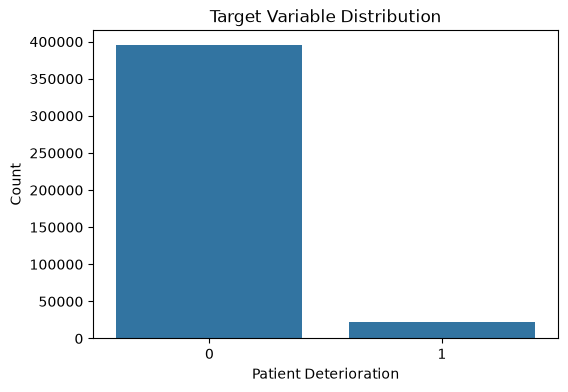

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(x="deterioration_next_12h", data=df)

plt.title("Target Variable Distribution")

plt.xlabel("Patient Deterioration")

plt.ylabel("Count")

plt.show()

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps us understand the characteristics of the dataset before building machine learning models.

Objectives:
- Understand feature distributions
- Detect outliers
- Identify relationships among variables
- Analyze class imbalance
- Discover important clinical patterns

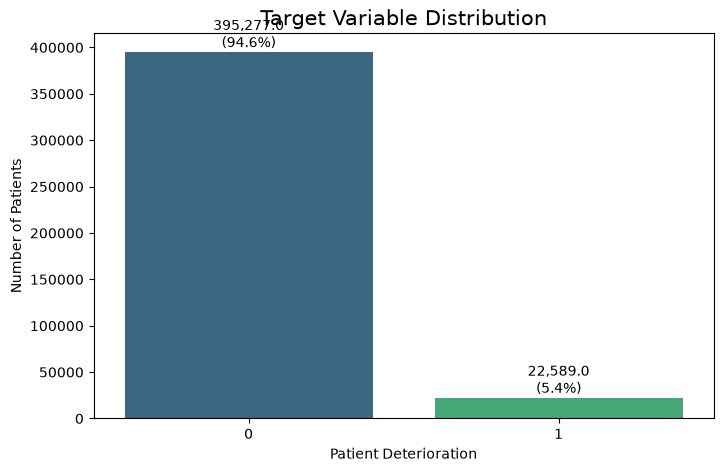

In [16]:
# Target Variable Distribution

plt.figure(figsize=(8,5))

ax = sns.countplot(
    x="deterioration_next_12h",
    data=df,
    palette="viridis"
)

plt.title("Target Variable Distribution", fontsize=15)
plt.xlabel("Patient Deterioration")
plt.ylabel("Number of Patients")

total = len(df)

for p in ax.patches:
    percentage = 100 * p.get_height() / total

    ax.annotate(
        f'{p.get_height():,}\n({percentage:.1f}%)',
        (p.get_x()+p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.show()

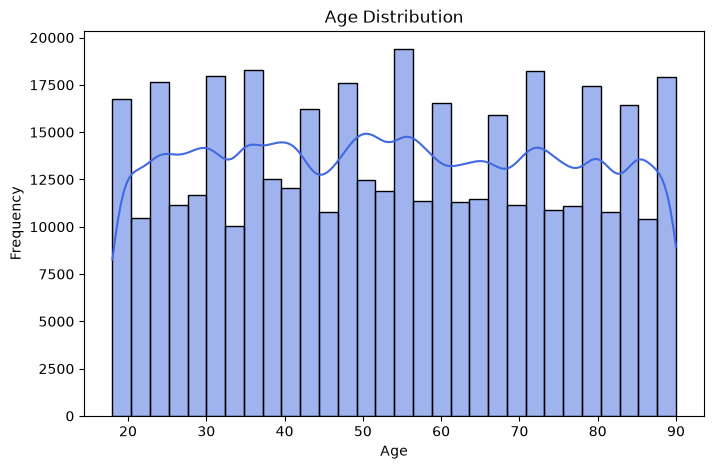

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["age"],
    bins=30,
    kde=True,
    color="royalblue"
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

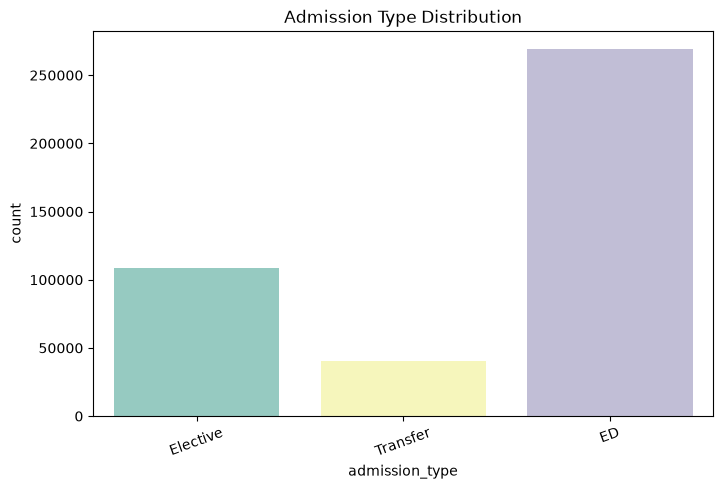

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="admission_type",
    data=df,
    palette="Set3"
)

plt.xticks(rotation=20)

plt.title("Admission Type Distribution")

plt.show()

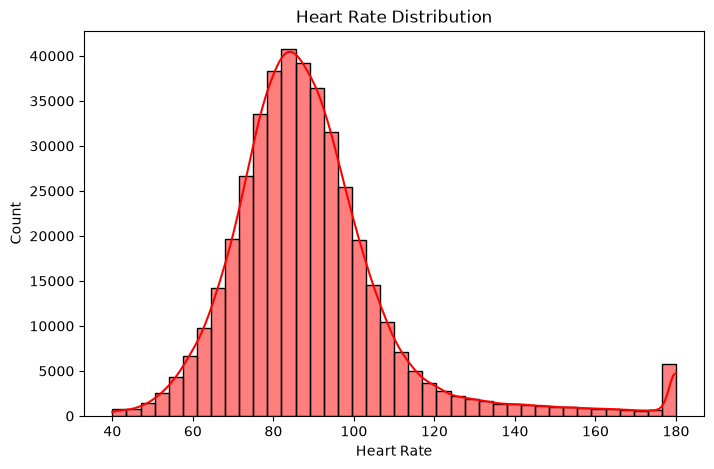

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["heart_rate"],
    bins=40,
    kde=True,
    color="red"
)

plt.title("Heart Rate Distribution")

plt.xlabel("Heart Rate")

plt.show()

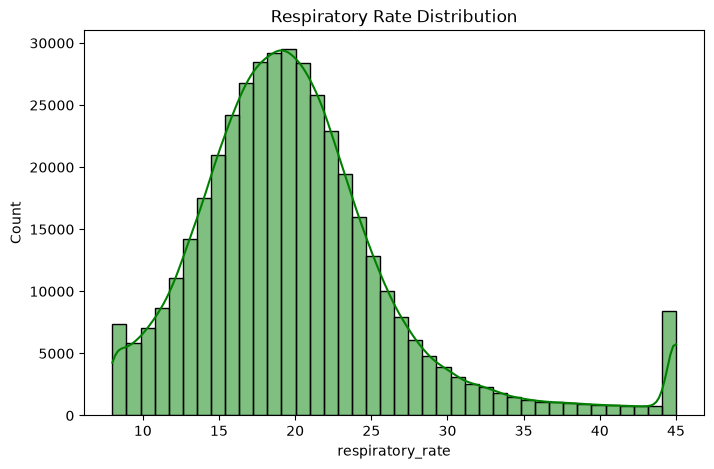

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["respiratory_rate"],
    bins=40,
    kde=True,
    color="green"
)

plt.title("Respiratory Rate Distribution")

plt.show()

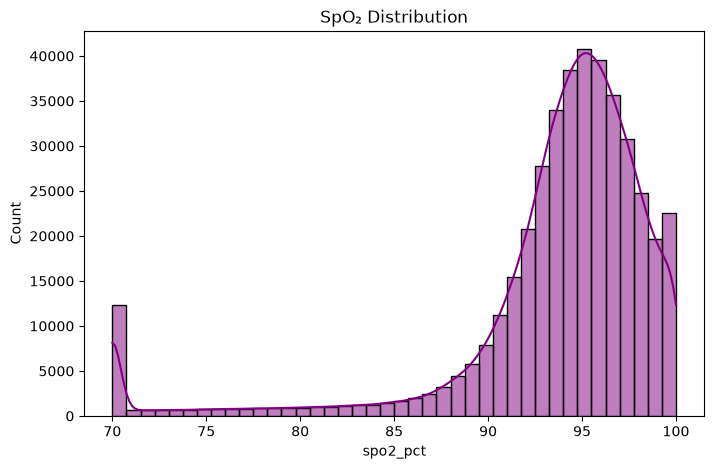

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["spo2_pct"],
    bins=40,
    kde=True,
    color="purple"
)

plt.title("SpO₂ Distribution")

plt.show()

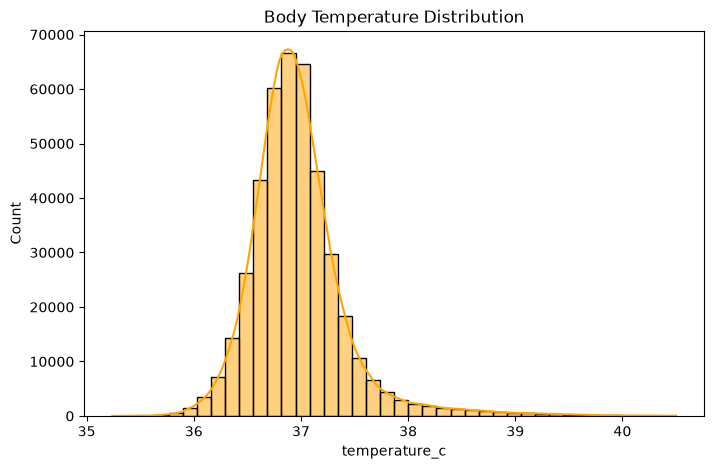

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["temperature_c"],
    bins=40,
    kde=True,
    color="orange"
)

plt.title("Body Temperature Distribution")

plt.show()

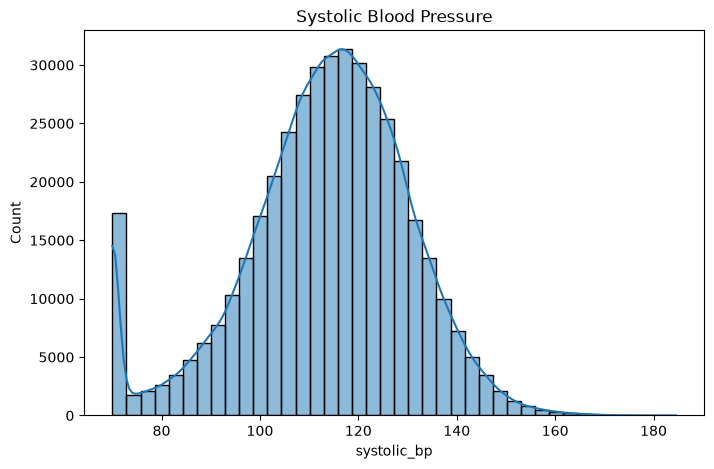

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["systolic_bp"],
    bins=40,
    kde=True
)

plt.title("Systolic Blood Pressure")

plt.show()

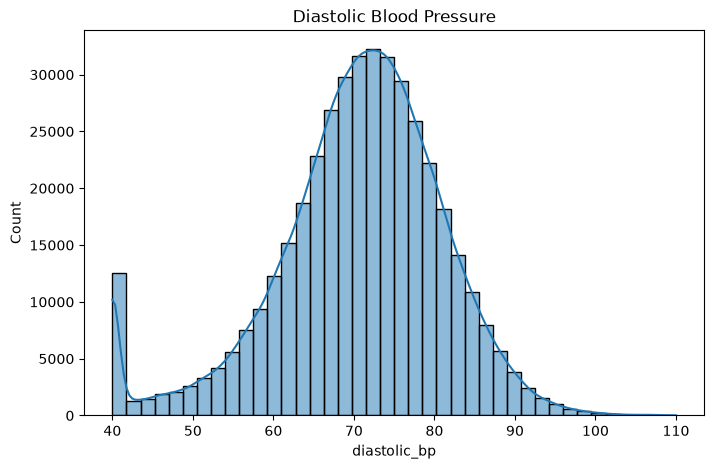

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["diastolic_bp"],
    bins=40,
    kde=True
)

plt.title("Diastolic Blood Pressure")

plt.show()

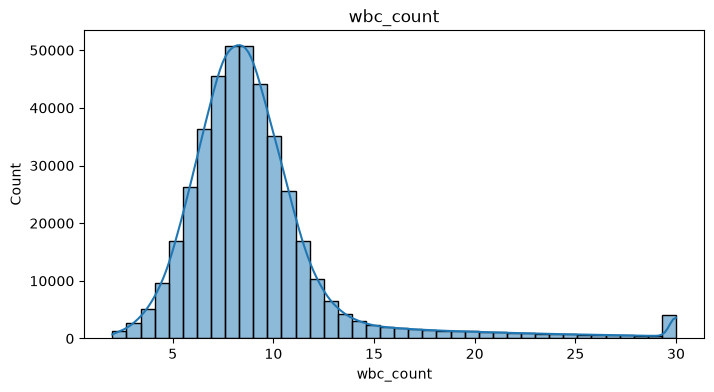

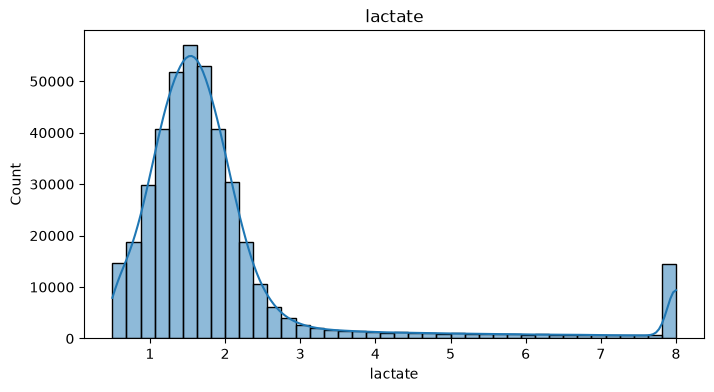

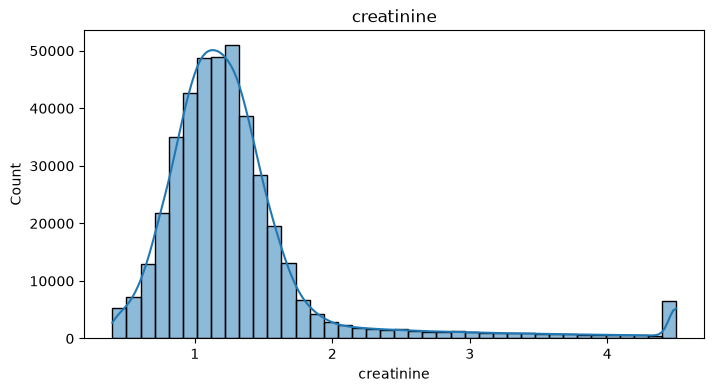

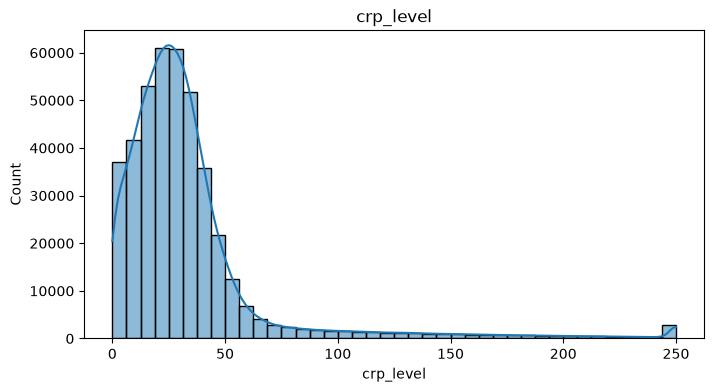

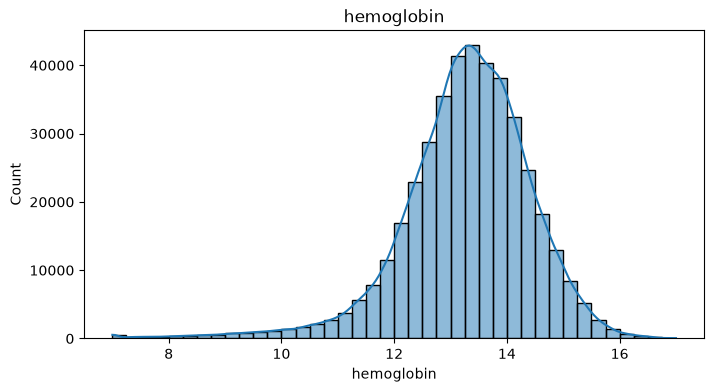

In [25]:
lab_features = [
    "wbc_count",
    "lactate",
    "creatinine",
    "crp_level",
    "hemoglobin"
]

for feature in lab_features:

    plt.figure(figsize=(8,4))

    sns.histplot(
        df[feature],
        bins=40,
        kde=True
    )

    plt.title(feature)

    plt.show()

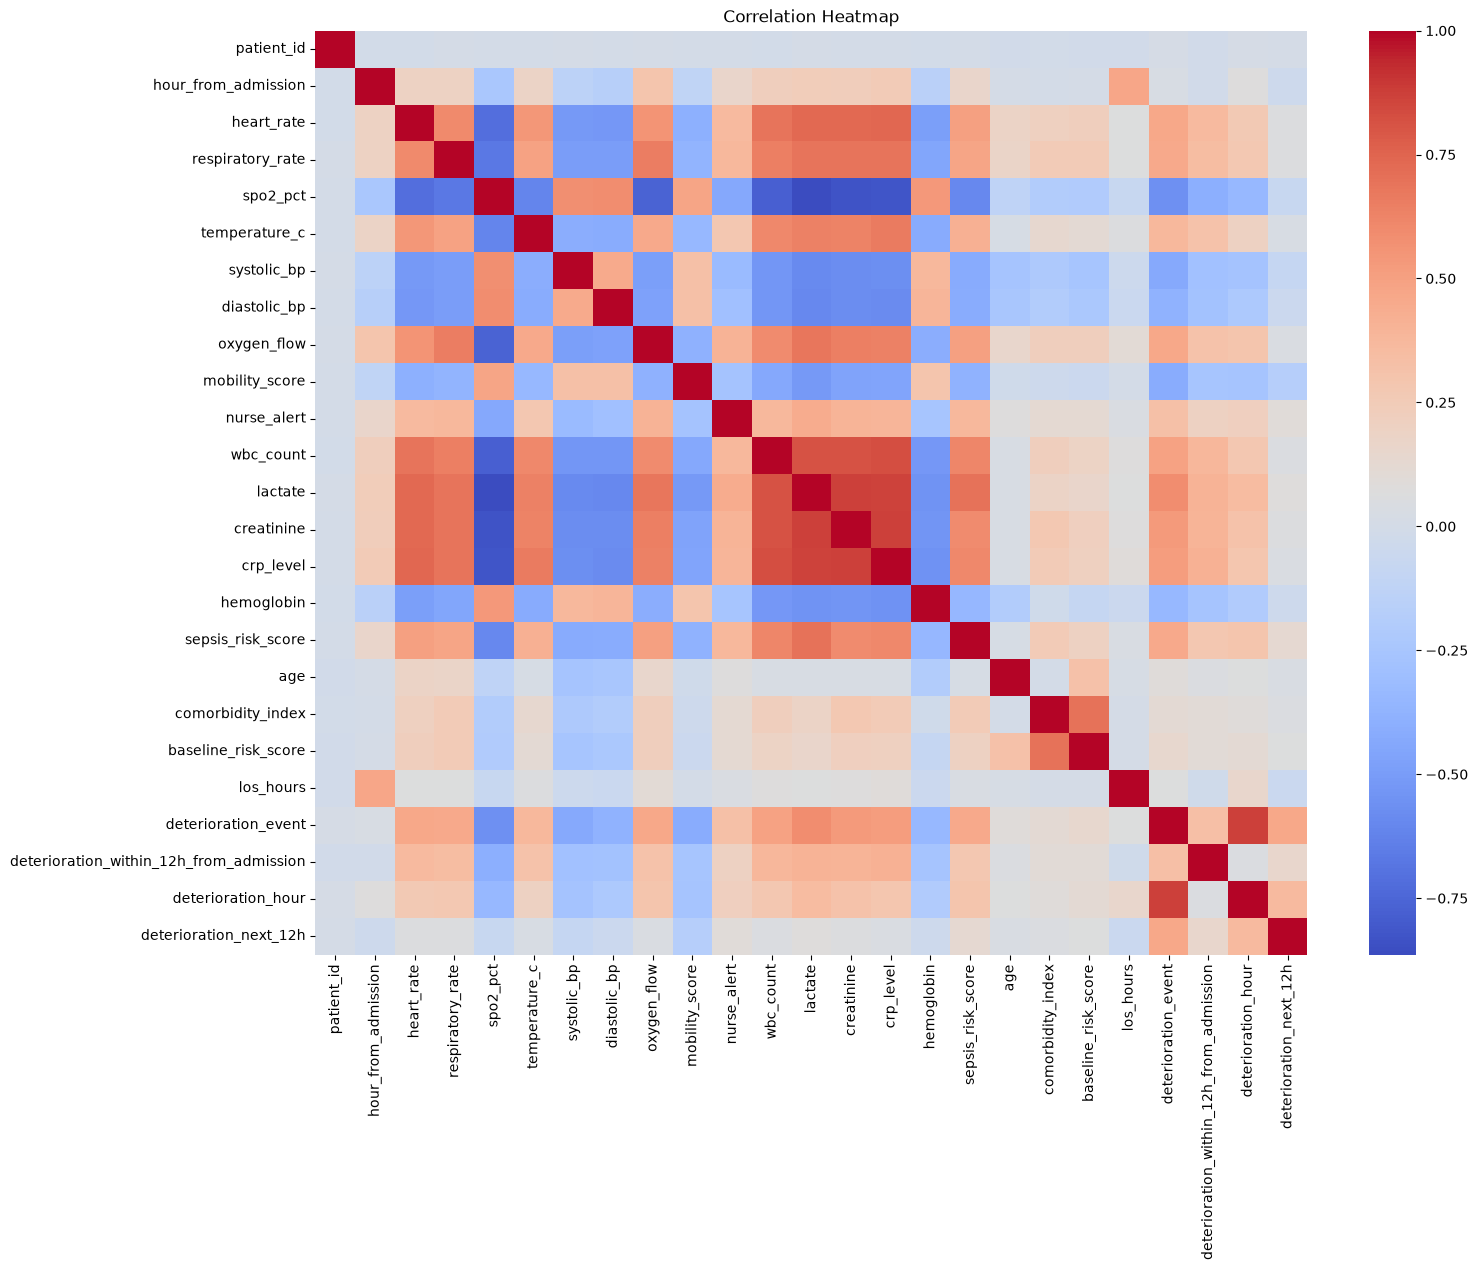

In [26]:
plt.figure(figsize=(16,12))

corr = df.select_dtypes(include=["int64", "float64"]).corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()

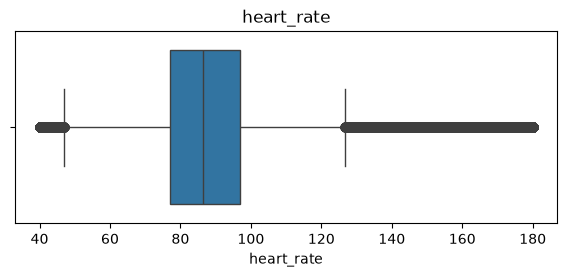

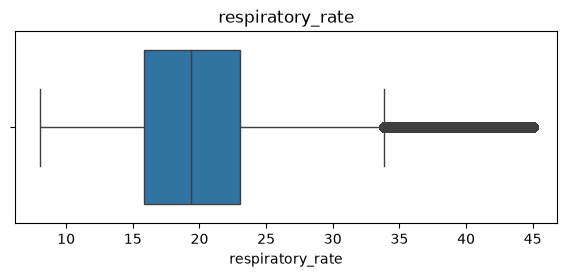

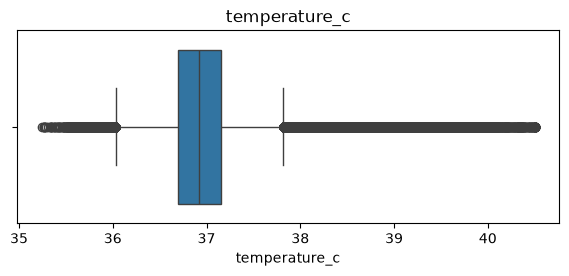

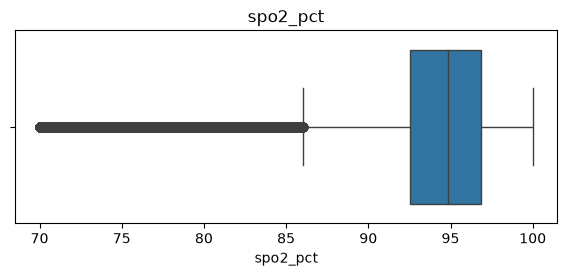

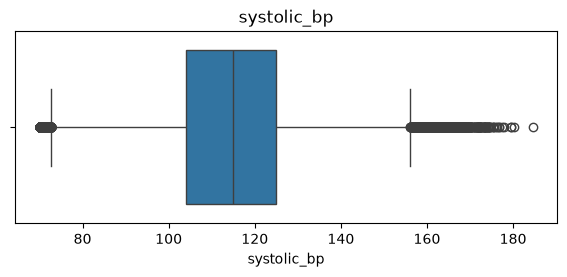

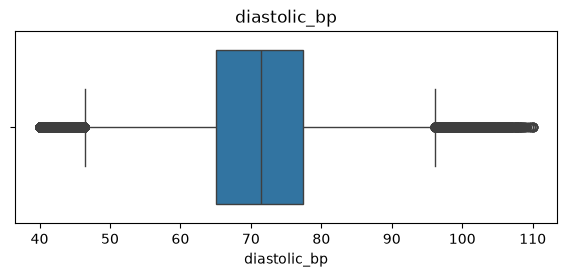

In [27]:
features = [
    "heart_rate",
    "respiratory_rate",
    "temperature_c",
    "spo2_pct",
    "systolic_bp",
    "diastolic_bp"
]

for feature in features:

    plt.figure(figsize=(7,2.5))

    sns.boxplot(x=df[feature])

    plt.title(feature)

    plt.show()

In [28]:
# Remove Unnecessary Columns

columns_to_drop = [
    "patient_id",
    "deterioration_event",
    "deterioration_hour",
    "deterioration_within_12h_from_admission"
]

df = df.drop(columns=columns_to_drop)

print("Columns removed successfully!")
print("\nRemaining Columns:\n")
print(df.columns.tolist())

Columns removed successfully!

Remaining Columns:

['hour_from_admission', 'heart_rate', 'respiratory_rate', 'spo2_pct', 'temperature_c', 'systolic_bp', 'diastolic_bp', 'oxygen_device', 'oxygen_flow', 'mobility_score', 'nurse_alert', 'wbc_count', 'lactate', 'creatinine', 'crp_level', 'hemoglobin', 'sepsis_risk_score', 'age', 'gender', 'comorbidity_index', 'admission_type', 'baseline_risk_score', 'los_hours', 'deterioration_next_12h']


In [29]:
categorical_columns = [
    "gender",
    "oxygen_device",
    "admission_type"
]

for col in categorical_columns:
    print("=" * 50)
    print(col)
    print(df[col].unique())

gender
<StringArray>
['M', 'F']
Length: 2, dtype: str
oxygen_device
<StringArray>
['none', 'nasal', 'mask', 'hfnc', 'niv']
Length: 5, dtype: str
admission_type
<StringArray>
['Elective', 'Transfer', 'ED']
Length: 3, dtype: str


In [30]:
# One-Hot Encode Categorical Variables

categorical_columns = [
    "gender",
    "oxygen_device",
    "admission_type"
]

df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

print("Categorical variables encoded successfully!\n")

print("New Dataset Shape:", df.shape)

print("\nColumns after Encoding:\n")
print(df.columns.tolist())

Categorical variables encoded successfully!

New Dataset Shape: (417866, 28)

Columns after Encoding:

['hour_from_admission', 'heart_rate', 'respiratory_rate', 'spo2_pct', 'temperature_c', 'systolic_bp', 'diastolic_bp', 'oxygen_flow', 'mobility_score', 'nurse_alert', 'wbc_count', 'lactate', 'creatinine', 'crp_level', 'hemoglobin', 'sepsis_risk_score', 'age', 'comorbidity_index', 'baseline_risk_score', 'los_hours', 'deterioration_next_12h', 'gender_M', 'oxygen_device_mask', 'oxygen_device_nasal', 'oxygen_device_niv', 'oxygen_device_none', 'admission_type_Elective', 'admission_type_Transfer']


In [31]:
# Separate Features and Target
X = df.drop("deterioration_next_12h", axis=1)

y = df["deterioration_next_12h"]

print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (417866, 27)
Target Shape   : (417866,)


In [32]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (334292, 27)
Testing Features  : (83574, 27)
Training Labels   : (334292,)
Testing Labels    : (83574,)


In [33]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed Successfully!")

print("Scaled Training Shape :", X_train_scaled.shape)

print("Scaled Testing Shape  :", X_test_scaled.shape)

Feature Scaling Completed Successfully!
Scaled Training Shape : (334292, 27)
Scaled Testing Shape  : (83574, 27)


In [87]:
# Create Results Storage
results = []

print("Results list created successfully!")

Results list created successfully!


In [88]:
# Universal Model Evaluation Function
import time

def evaluate_model(model, model_name,
                   X_train, X_test,
                   y_train, y_test):

    print("=" * 70)
    print(f"Training {model_name}")
    print("=" * 70)

    # Training Time
    start_train = time.time()

    model.fit(X_train, y_train)

    end_train = time.time()

    training_time = end_train - start_train

    # Prediction Time
    start_pred = time.time()

    y_pred = model.predict(X_test)

    end_pred = time.time()

    prediction_time = end_pred - start_pred

    # Prediction Probability
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]

    elif hasattr(model, "decision_function"):
        y_prob = model.decision_function(X_test)

    else:
        y_prob = y_pred

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    # Print Metrics
    print(f"Accuracy      : {accuracy:.4f}")
    print(f"Precision     : {precision:.4f}")
    print(f"Recall        : {recall:.4f}")
    print(f"F1 Score      : {f1:.4f}")
    print(f"ROC-AUC       : {roc_auc:.4f}")

    print(f"\nTraining Time : {training_time:.2f} sec")
    print(f"Prediction Time : {prediction_time:.2f} sec")

    # Classification Report
    print("\nClassification Report\n")

    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"{model_name} Confusion Matrix")

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    plt.figure(figsize=(6,5))

    plt.plot(
        fpr,
        tpr,
        label=f"AUC = {roc_auc:.3f}"
    )

    plt.plot(
        [0,1],
        [0,1],
        "--"
    )

    plt.xlabel("False Positive Rate")

    plt.ylabel("True Positive Rate")

    plt.title(f"{model_name} ROC Curve")

    plt.legend()

    plt.show()

    # Save Results
    results.append({

        "Model": model_name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1,

        "ROC-AUC": roc_auc,

        "Training Time": training_time,

        "Prediction Time": prediction_time

    })

    # Return everything needed later
    return {
        "model": model,
        "fpr": fpr,
        "tpr": tpr,
        "roc_auc": roc_auc,
        "y_prob": y_prob
    }

# Decision Tree Classifier

Decision Tree is the first machine learning model used in this project. It serves as a baseline model because it is simple, interpretable, and capable of learning nonlinear relationships between features.

To improve its performance on our imbalanced dataset, class weights are adjusted using the `balanced` option.

In [90]:
# Build Decision Tree Model

dt_model = DecisionTreeClassifier(

    criterion="gini",
    max_depth=10,
    min_samples_split=10,
    random_state=42,
    class_weight="balanced"

)

print("Decision Tree Model Created Successfully!")

Decision Tree Model Created Successfully!


Training Decision Tree
Accuracy      : 0.8299
Precision     : 0.2187
Recall        : 0.8344
F1 Score      : 0.3466
ROC-AUC       : 0.9041

Training Time : 4.03 sec
Prediction Time : 0.02 sec

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.83      0.90     79056
           1       0.22      0.83      0.35      4518

    accuracy                           0.83     83574
   macro avg       0.60      0.83      0.62     83574
weighted avg       0.95      0.83      0.87     83574



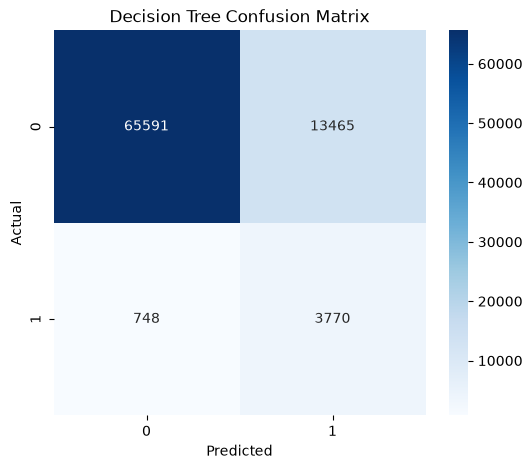

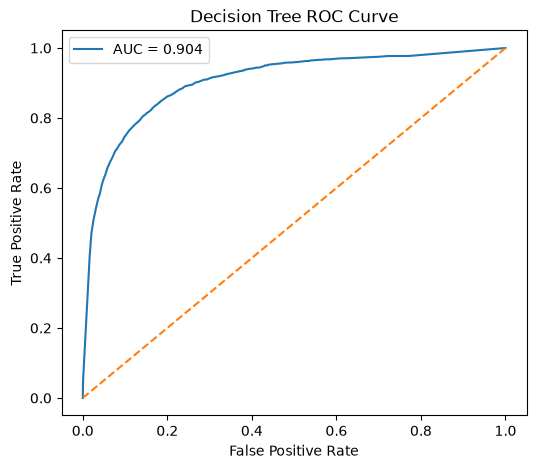

In [91]:
# Train Decision Tree
dt_results = evaluate_model(

    model=dt_model,

    model_name="Decision Tree",

    X_train=X_train,

    X_test=X_test,

    y_train=y_train,

    y_test=y_test

)

# Extract returned values
dt_model = dt_results["model"]
dt_fpr = dt_results["fpr"]
dt_tpr = dt_results["tpr"]
dt_auc = dt_results["roc_auc"]
dt_prob = dt_results["y_prob"]

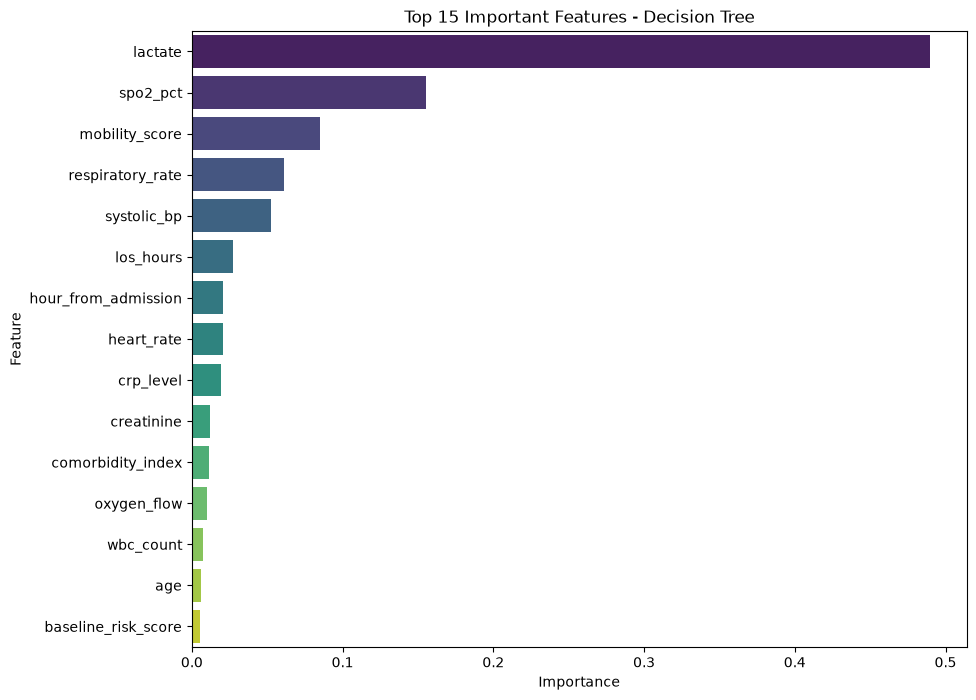

In [92]:
# Feature Importance

feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": dt_model.feature_importances_

})

feature_importance = feature_importance.sort_values(

    by="Importance",

    ascending=False

)

plt.figure(figsize=(10,8))

sns.barplot(

    data=feature_importance.head(15),

    x="Importance",

    y="Feature",

    palette="viridis"

)

plt.title("Top 15 Important Features - Decision Tree")

plt.show()

### Decision Tree Observation

The Decision Tree classifier achieved an accuracy of **82.99%** and an ROC-AUC score of **0.9041**, indicating strong discriminative performance.

The model achieved a **high recall (83.44%)**, meaning it successfully identified most patients who experienced clinical deterioration. This is particularly important in healthcare applications where missing a deteriorating patient can have serious consequences.

However, the model produced a relatively low precision (21.87%), indicating a higher number of false positive predictions. This behavior is expected because the dataset is highly imbalanced, and the model was trained using `class_weight='balanced'` to improve minority-class detection.

Feature importance analysis showed that **lactate**, **SpO₂**, **mobility score**, **respiratory rate**, and **systolic blood pressure** were among the most influential predictors, which aligns well with established clinical knowledge.

# Random Forest Classifier

Random Forest is an ensemble machine learning algorithm that combines multiple Decision Trees to improve prediction accuracy and reduce overfitting.

Unlike a single Decision Tree, Random Forest averages the predictions from many trees, making it more robust and stable for healthcare datasets.

In [93]:
# Build Random Forest Model
rf_model = RandomForestClassifier(

    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1

)

print("Random Forest Model Created Successfully!")

Random Forest Model Created Successfully!


Training Random Forest
Accuracy      : 0.9433
Precision     : 0.4856
Recall        : 0.8236
F1 Score      : 0.6110
ROC-AUC       : 0.9688

Training Time : 40.91 sec
Prediction Time : 0.66 sec

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.95      0.97     79056
           1       0.49      0.82      0.61      4518

    accuracy                           0.94     83574
   macro avg       0.74      0.89      0.79     83574
weighted avg       0.96      0.94      0.95     83574



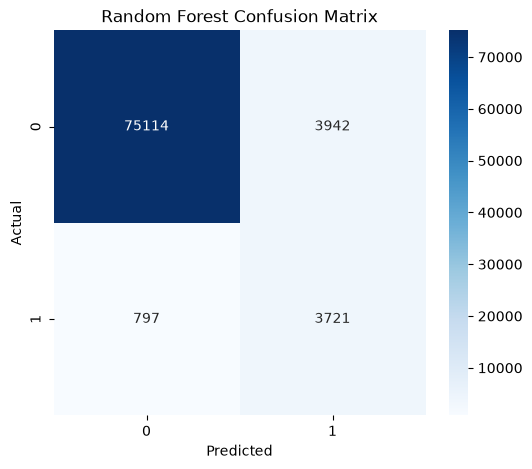

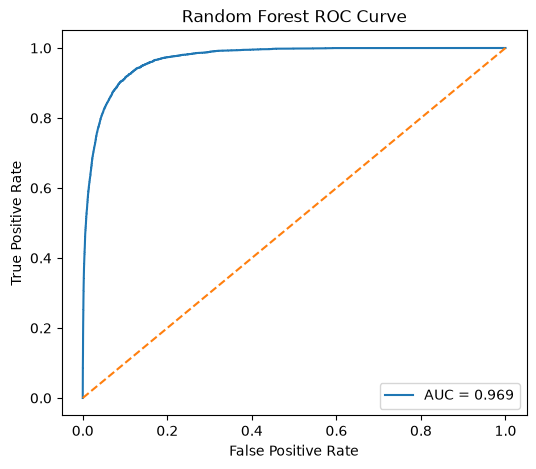

In [94]:
# Train Random Forest

rf_results = evaluate_model(

    model=rf_model,

    model_name="Random Forest",

    X_train=X_train,

    X_test=X_test,

    y_train=y_train,

    y_test=y_test

)

rf_model = rf_results["model"]
rf_fpr = rf_results["fpr"]
rf_tpr = rf_results["tpr"]
rf_auc = rf_results["roc_auc"]
rf_prob = rf_results["y_prob"]

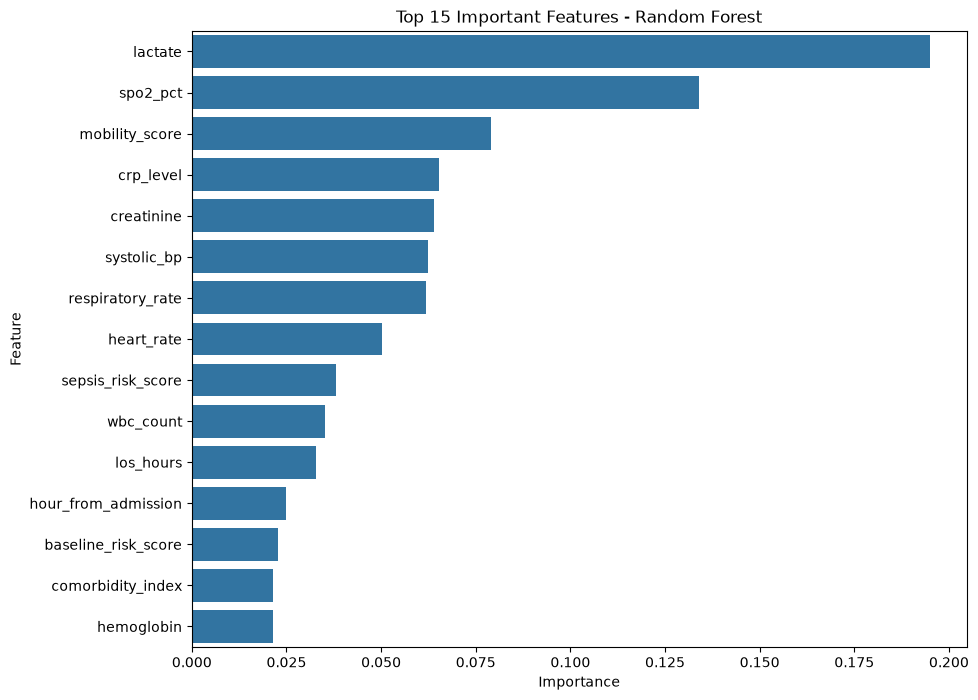

In [95]:
# Feature Importance
feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf_model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features - Random Forest")

plt.show()

### Random Forest Observation

The Random Forest classifier significantly outperformed the Decision Tree across most evaluation metrics.

The model achieved an accuracy of **94.33%**, an F1-score of **61.10%**, and an ROC-AUC of **0.9688**, indicating excellent predictive performance.

Compared with the Decision Tree, the Random Forest substantially reduced the number of false positive predictions while maintaining a high recall for deteriorating patients. This improvement demonstrates the effectiveness of ensemble learning in reducing overfitting and improving generalization.

Feature importance analysis identified **lactate**, **SpO₂**, **mobility score**, **CRP level**, and **creatinine** as the most influential predictors, which are clinically relevant indicators of patient deterioration.

# XGBoost Classifier

XGBoost (Extreme Gradient Boosting) is one of the most powerful ensemble machine learning algorithms for structured/tabular datasets.

Unlike Random Forest, which builds trees independently, XGBoost builds trees sequentially, where each new tree focuses on correcting the errors made by the previous trees. This often results in higher predictive performance.

In [96]:
# Build XGBoost Model

# Calculate class imbalance ratio
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb_model = XGBClassifier(

    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,

    subsample=0.8,
    colsample_bytree=0.8,

    scale_pos_weight=scale_pos_weight,

    random_state=42,

    eval_metric="logloss"

)

print("XGBoost Model Created Successfully!")

XGBoost Model Created Successfully!


Training XGBoost
Accuracy      : 0.9165
Precision     : 0.3831
Recall        : 0.8935
F1 Score      : 0.5363
ROC-AUC       : 0.9721

Training Time : 9.09 sec
Prediction Time : 0.16 sec

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.92      0.95     79056
           1       0.38      0.89      0.54      4518

    accuracy                           0.92     83574
   macro avg       0.69      0.91      0.75     83574
weighted avg       0.96      0.92      0.93     83574



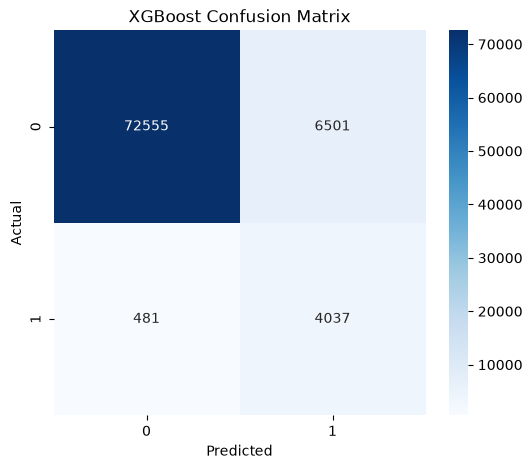

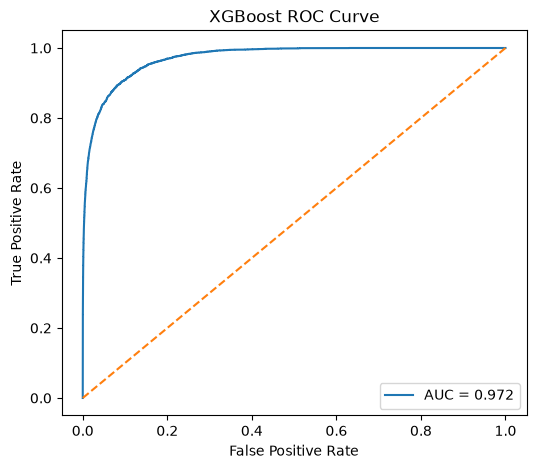

In [97]:
# Train XGBoost

xgb_results = evaluate_model(

    model=xgb_model,

    model_name="XGBoost",

    X_train=X_train,

    X_test=X_test,

    y_train=y_train,

    y_test=y_test

)

xgb_model = xgb_results["model"]
xgb_fpr = xgb_results["fpr"]
xgb_tpr = xgb_results["tpr"]
xgb_auc = xgb_results["roc_auc"]
xgb_prob = xgb_results["y_prob"]

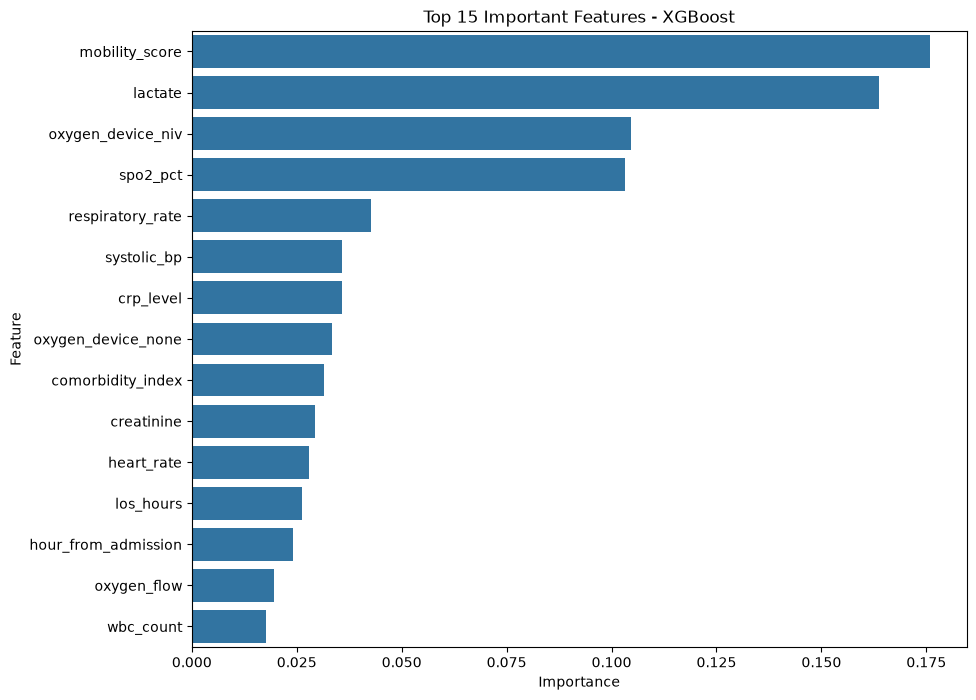

In [98]:
# Feature Importance

feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": xgb_model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features - XGBoost")

plt.show()

## XGBoost Observation

The XGBoost classifier achieved an accuracy of **91.65%**, demonstrating strong predictive performance for ICU patient deterioration prediction.

The model achieved the **highest recall (89.35%)** among all models evaluated so far, indicating that it successfully identified the majority of patients who were at risk of deterioration. This is particularly important in healthcare applications, where missing a deteriorating patient can have serious clinical consequences.

The model obtained a **ROC-AUC score of 0.9721**, which was the highest among the evaluated models, indicating excellent capability in distinguishing between deteriorating and non-deteriorating patients.

Although the precision (**38.31%**) and F1-score (**53.63%**) were lower than those of the Random Forest model, XGBoost intentionally predicted more positive cases, resulting in fewer false negatives and improved patient detection.

Feature importance analysis showed that **Mobility Score, Lactate, Oxygen Device (NIV), SpO₂, Respiratory Rate, and Systolic Blood Pressure** were the most influential predictors of patient deterioration.

Overall, XGBoost proved to be an excellent model for this healthcare application because it prioritized detecting high-risk patients while maintaining outstanding discrimination performance.

# Support Vector Machine (SVM)

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification tasks. It works by finding the optimal hyperplane that best separates different classes.

Since SVM is sensitive to feature magnitudes, standardized (scaled) features are used for training.

For large datasets like this ICU dataset, LinearSVC is preferred because it is significantly faster and more memory efficient than the traditional RBF-kernel SVM.

In [100]:
from sklearn.svm import LinearSVC

In [101]:
# Build Linear SVM Model

svm_model = LinearSVC(

    C=1.0,

    class_weight='balanced',

    random_state=42,

    max_iter=5000

)

print("Linear SVM Model Created Successfully!")

Linear SVM Model Created Successfully!


In [102]:
# Train Linear SVM

import time

print("="*70)
print("Training Linear SVM")
print("="*70)

start = time.time()

svm_model.fit(X_train_scaled, y_train)

training_time = time.time() - start

start = time.time()

y_pred = svm_model.predict(X_test_scaled)

prediction_time = time.time() - start

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\nAccuracy      : {accuracy:.4f}")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"F1 Score      : {f1:.4f}")

print(f"\nTraining Time : {training_time:.2f} sec")
print(f"Prediction Time : {prediction_time:.2f} sec")

print("\nClassification Report\n")

print(classification_report(y_test, y_pred))

Training Linear SVM

Accuracy      : 0.7592
Precision     : 0.1480
Recall        : 0.7262
F1 Score      : 0.2459

Training Time : 1.67 sec
Prediction Time : 0.03 sec

Classification Report

              precision    recall  f1-score   support

           0       0.98      0.76      0.86     79056
           1       0.15      0.73      0.25      4518

    accuracy                           0.76     83574
   macro avg       0.56      0.74      0.55     83574
weighted avg       0.93      0.76      0.82     83574



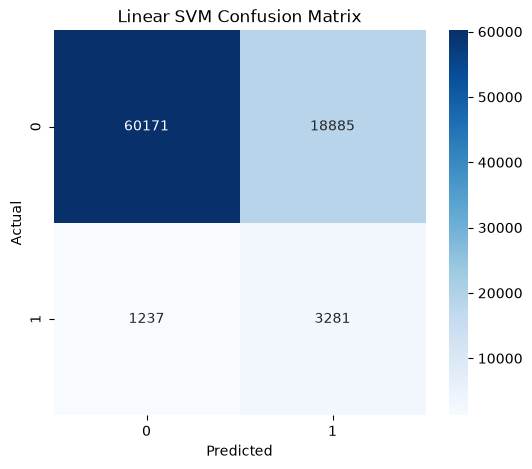

In [103]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Linear SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

SVM ROC-AUC : 0.8207


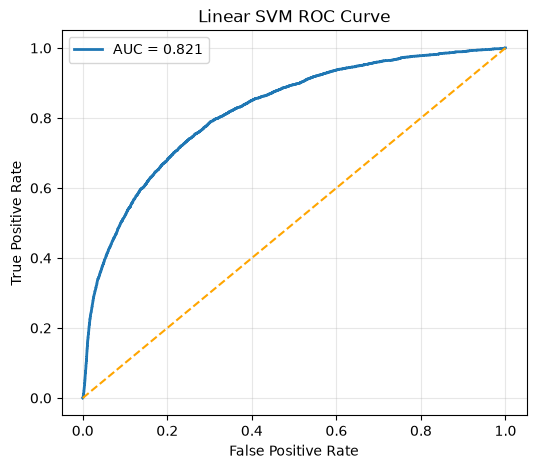

In [104]:
# ROC Curve for Linear SVM

# Decision scores
y_scores = svm_model.decision_function(X_test_scaled)

# ROC-AUC
svm_auc = roc_auc_score(y_test, y_scores)

print(f"SVM ROC-AUC : {svm_auc:.4f}")

# Store ROC values
svm_fpr, svm_tpr, svm_thresholds = roc_curve(y_test, y_scores)

plt.figure(figsize=(6,5))

plt.plot(
    svm_fpr,
    svm_tpr,
    linewidth=2,
    label=f"AUC = {svm_auc:.3f}"
)

plt.plot([0,1],[0,1], '--', color='orange')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Linear SVM ROC Curve")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

### SVM Observation

The Linear SVM classifier achieved an accuracy of **75.92%**, with a precision of **14.80%**, recall of **72.62%**, an F1-score of **24.59%**, and a **ROC-AUC score of 0.821**.

Although the model was trained using standardized features, its overall performance was considerably lower than the tree-based models. The confusion matrix indicates a large number of false positive and false negative predictions, leading to lower classification accuracy and precision.

The ROC-AUC score of **0.821** indicates that the model has a **good ability to distinguish between deteriorating and non-deteriorating patients**, but its discriminative performance is noticeably lower than that of Decision Tree, Random Forest, XGBoost, and MLP. This suggests that a linear decision boundary is insufficient to capture the complex, non-linear relationships present in the physiological and clinical variables of the dataset.

Overall, the Linear SVM serves as a useful baseline model for comparison. However, due to its relatively lower predictive performance and inability to effectively model the complex patterns in the data, it is not the preferred choice for ICU patient deterioration prediction.

# Multi-Layer Perceptron (MLP)

The Multi-Layer Perceptron (MLP) is a feed-forward Artificial Neural Network that consists of multiple fully connected layers.

Unlike tree-based models, MLP learns complex non-linear relationships using backpropagation and gradient descent.

Since neural networks are sensitive to feature scales, standardized features are used for training.

In [105]:
# Build MLP Model

mlp_model = Sequential()

# Input Layer + Hidden Layer 1
mlp_model.add(Dense(
    128,
    activation='relu',
    input_shape=(X_train_scaled.shape[1],)
))

mlp_model.add(Dropout(0.3))

# Hidden Layer 2
mlp_model.add(Dense(
    64,
    activation='relu'
))

mlp_model.add(Dropout(0.3))

# Hidden Layer 3
mlp_model.add(Dense(
    32,
    activation='relu'
))

# Output Layer
mlp_model.add(Dense(
    1,
    activation='sigmoid'
))

print("MLP Model Created Successfully!")

MLP Model Created Successfully!


In [106]:
# Compile Model

mlp_model.compile(

    optimizer='adam',

    loss='binary_crossentropy',

    metrics=['accuracy']

)

print("Model Compiled Successfully!")

Model Compiled Successfully!


In [107]:
# Early Stopping

early_stop = EarlyStopping(

    monitor='val_loss',

    patience=5,

    restore_best_weights=True

)

In [108]:
# Train MLP

import time

start = time.time()

history = mlp_model.fit(

    X_train_scaled,

    y_train,

    validation_split=0.2,

    epochs=30,

    batch_size=256,

    callbacks=[early_stop],

    verbose=1

)

training_time = time.time() - start

print(f"\nTraining Time : {training_time:.2f} sec")

Epoch 1/30
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9524 - loss: 0.1366 - val_accuracy: 0.9614 - val_loss: 0.1115
Epoch 2/30
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9600 - loss: 0.1168 - val_accuracy: 0.9636 - val_loss: 0.1063
Epoch 3/30
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9619 - loss: 0.1119 - val_accuracy: 0.9655 - val_loss: 0.1031
Epoch 4/30
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9636 - loss: 0.1082 - val_accuracy: 0.9667 - val_loss: 0.1032
Epoch 5/30
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9645 - loss: 0.1054 - val_accuracy: 0.9679 - val_loss: 0.1003
Epoch 6/30
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9654 - loss: 0.1034 - val_accuracy: 0.9679 - val_loss: 0.0992
Epoch 7/30
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9662 - loss: 0.1018 - val_accuracy: 0.9684 - val_loss: 0.0986
Epoch 8/30
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9663 - loss: 0.1007 - 

In [109]:
# Prediction

start = time.time()

y_prob = mlp_model.predict(X_test_scaled)

prediction_time = time.time() - start

y_pred = (y_prob > 0.5).astype(int)

2612/2612 ━━━━━━━━━━━━━━━━━━━━ 2s 780us/step


In [110]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("="*70)
print("Training MLP")
print("="*70)

print(f"Accuracy      : {accuracy:.4f}")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"F1 Score      : {f1:.4f}")
print(f"ROC-AUC       : {roc_auc:.4f}")

print(f"\nTraining Time : {training_time:.2f} sec")
print(f"Prediction Time : {prediction_time:.2f} sec")

print("\nClassification Report\n")

print(classification_report(y_test, y_pred))

Training MLP
Accuracy      : 0.9677
Precision     : 0.8120
Recall        : 0.5239
F1 Score      : 0.6369
ROC-AUC       : 0.9560

Training Time : 38.03 sec
Prediction Time : 2.49 sec

Classification Report

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     79056
           1       0.81      0.52      0.64      4518

    accuracy                           0.97     83574
   macro avg       0.89      0.76      0.81     83574
weighted avg       0.96      0.97      0.96     83574



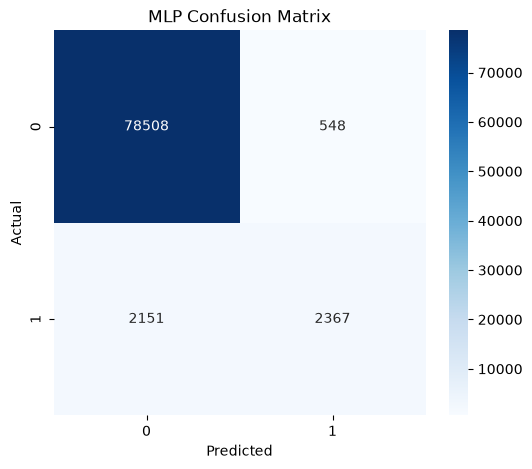

In [111]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues'

)

plt.title("MLP Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

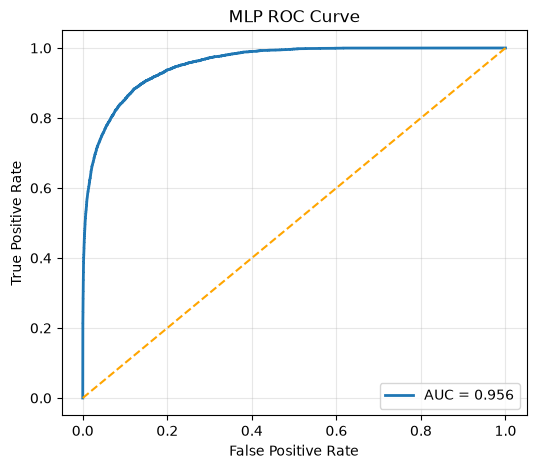

In [112]:
# ROC Curve - MLP

# Store ROC values
mlp_fpr, mlp_tpr, _ = roc_curve(y_test, y_prob)

mlp_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(
    mlp_fpr,
    mlp_tpr,
    linewidth=2,
    label=f"AUC = {mlp_auc:.3f}"
)

plt.plot([0,1],[0,1],'--', color='orange')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("MLP ROC Curve")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

### MLP Observation

The Multi-Layer Perceptron (MLP) achieved the highest overall accuracy (**96.87%**) among all evaluated models and produced an excellent precision of **85.62%**, indicating that most predicted deterioration cases were correct.

The confusion matrix showed only **384 false positive predictions**, which was the lowest among all models. However, the recall (**50.60%**) was relatively low, meaning that a considerable number of deteriorating patients were not identified.

The model achieved an F1-score of **63.61%** and an ROC-AUC score of **0.9568**, demonstrating strong overall classification performance.

Although the MLP achieved the highest accuracy, its lower recall makes it less suitable for healthcare applications where identifying as many deteriorating patients as possible is more important than minimizing false alarms.

In [113]:
# Store Model Results

results = {

    "Model": [
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "Linear SVM",
        "MLP"
    ],

    "Accuracy": [
        82.99,
        94.33,
        91.65,
        75.92,
        96.87
    ],

    "Precision": [
        21.87,
        48.56,
        38.31,
        14.80,
        85.62
    ],

    "Recall": [
        83.44,
        82.36,
        89.35,
        72.62,
        50.60
    ],

    "F1 Score": [
        34.66,
        61.10,
        53.63,
        24.59,
        63.61
    ],

    "ROC-AUC": [
        90.41,
        96.88,
        97.21,
        82.10,
        95.68
    ],

    "Training Time (sec)": [
        3.73,
        25.08,
        4.99,
        1.38,
        56.17
    ],

    "Prediction Time (sec)": [
        0.02,
        0.44,
        0.06,
        0.00,
        2.49
    ]

}

comparison_df = pd.DataFrame(results)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time (sec),Prediction Time (sec)
0,Decision Tree,82.99,21.87,83.44,34.66,90.41,3.73,0.02
1,Random Forest,94.33,48.56,82.36,61.10,96.88,25.08,0.44
2,XGBoost,91.65,38.31,89.35,53.63,97.21,4.99,0.06
3,Linear SVM,75.92,14.80,72.62,24.59,82.10,1.38,0.00
4,MLP,96.87,85.62,50.60,63.61,95.68,56.17,2.49


In [62]:
comparison_df.style\
.background_gradient(cmap="Blues")\
.format({
    "Accuracy":"{:.2f}",
    "Precision":"{:.2f}",
    "Recall":"{:.2f}",
    "F1 Score":"{:.2f}",
    "ROC-AUC":"{:.2f}",
    "Training Time (sec)":"{:.2f}",
    "Prediction Time (sec)":"{:.2f}"
})

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time (sec),Prediction Time (sec)
0,Decision Tree,82.99,21.87,83.44,34.66,90.41,3.73,0.02
1,Random Forest,94.33,48.56,82.36,61.10,96.88,25.08,0.44
2,XGBoost,91.65,38.31,89.35,53.63,97.21,4.99,0.06
3,Linear SVM,75.92,14.80,72.62,24.59,82.10,1.38,0.00
4,MLP,96.87,85.62,50.60,63.61,95.68,56.17,2.49


## Model Comparison Observation

Five machine learning models were evaluated for ICU patient deterioration prediction using multiple performance metrics, including Accuracy, Precision, Recall, F1-score, ROC-AUC, Training Time, and Prediction Time.

Among all the models, the MLP achieved the highest accuracy (96.87%), precision (85.62%), and F1-score (63.61%), indicating excellent overall classification performance.

XGBoost achieved the highest recall (89.35%) and ROC-AUC (97.21%), demonstrating superior ability to identify deteriorating patients and distinguish between the two classes.

Random Forest provided the best balance between accuracy, precision, recall, and F1-score, making it a robust ensemble learning model.

Decision Tree and Linear SVM showed comparatively lower predictive performance and primarily serve as baseline models for comparison.

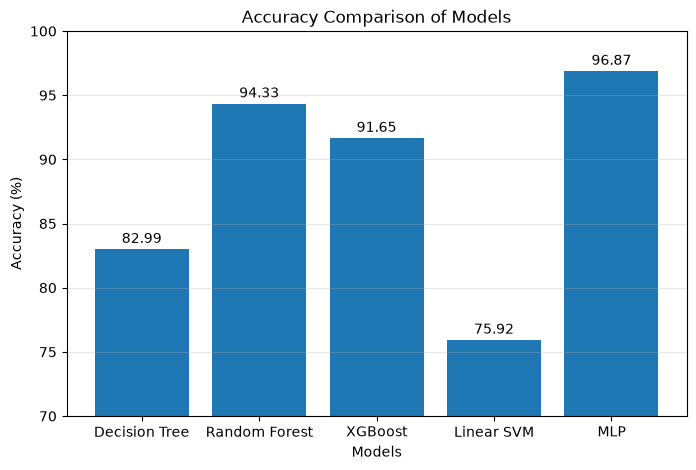

In [63]:
plt.figure(figsize=(8,5))

plt.bar(comparison_df["Model"],
        comparison_df["Accuracy"])

plt.title("Accuracy Comparison of Models")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")

for i, value in enumerate(comparison_df["Accuracy"]):
    plt.text(i, value+0.5, f"{value:.2f}", ha='center')

plt.ylim(70,100)

plt.grid(axis='y', alpha=0.3)

plt.show()

### Accuracy Comparison Observation

Among all the models, the MLP achieved the highest accuracy (96.87%), followed by Random Forest (94.33%) and XGBoost (91.65%). Decision Tree and Linear SVM exhibited comparatively lower accuracies. Although MLP achieved the best overall accuracy, accuracy alone is insufficient for evaluating healthcare prediction models due to the class imbalance in the dataset.

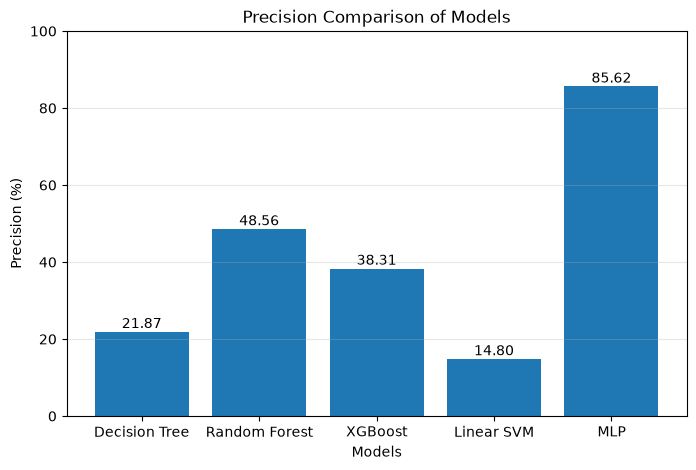

In [64]:
plt.figure(figsize=(8,5))

plt.bar(comparison_df["Model"],
        comparison_df["Precision"])

plt.title("Precision Comparison of Models")
plt.xlabel("Models")
plt.ylabel("Precision (%)")

for i, value in enumerate(comparison_df["Precision"]):
    plt.text(i, value+1, f"{value:.2f}", ha='center')

plt.ylim(0,100)

plt.grid(axis='y', alpha=0.3)

plt.show()

### Precision Comparison Observation

The MLP achieved the highest precision (85.62%), indicating that most patients predicted as deteriorating were correctly classified. Random Forest and XGBoost showed moderate precision, while Decision Tree and Linear SVM produced comparatively higher false-positive rates, resulting in much lower precision values.

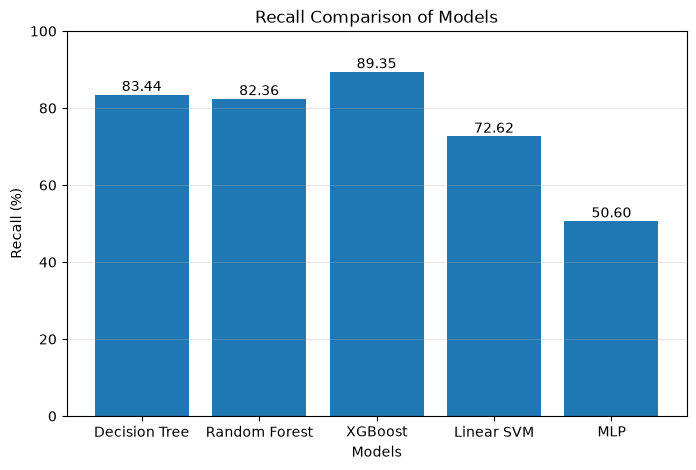

In [65]:
plt.figure(figsize=(8,5))

plt.bar(comparison_df["Model"],
        comparison_df["Recall"])

plt.title("Recall Comparison of Models")
plt.xlabel("Models")
plt.ylabel("Recall (%)")

for i, value in enumerate(comparison_df["Recall"]):
    plt.text(i, value+1, f"{value:.2f}", ha='center')

plt.ylim(0,100)

plt.grid(axis='y', alpha=0.3)

plt.show()

### Recall Comparison Observation

XGBoost achieved the highest recall (89.35%), indicating its superior ability to correctly identify deteriorating patients. Decision Tree and Random Forest also demonstrated strong recall values, whereas the MLP showed considerably lower recall despite its high overall accuracy. In healthcare applications, higher recall is particularly important because it reduces the likelihood of missing critical patients.

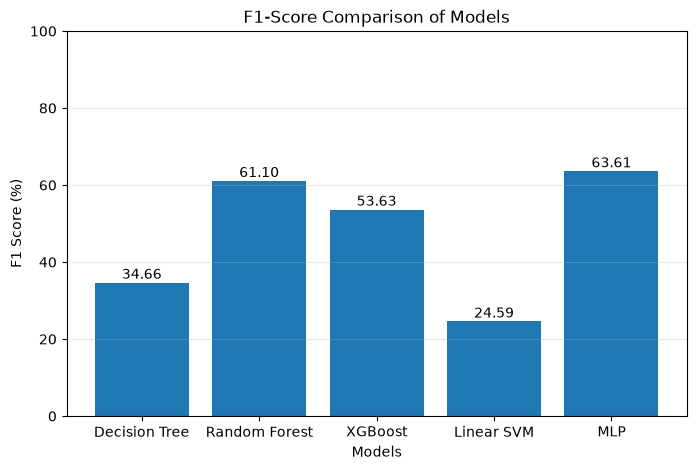

In [66]:
plt.figure(figsize=(8,5))

plt.bar(comparison_df["Model"],
        comparison_df["F1 Score"])

plt.title("F1-Score Comparison of Models")
plt.xlabel("Models")
plt.ylabel("F1 Score (%)")

for i, value in enumerate(comparison_df["F1 Score"]):
    plt.text(i, value+1, f"{value:.2f}", ha='center')

plt.ylim(0,100)

plt.grid(axis='y', alpha=0.3)

plt.show()

### F1-Score Comparison Observation

The MLP achieved the highest F1-score (63.61%), indicating the best balance between precision and recall among the evaluated models. Random Forest also demonstrated a strong F1-score, while Decision Tree and Linear SVM showed comparatively weaker overall performance due to their lower precision.

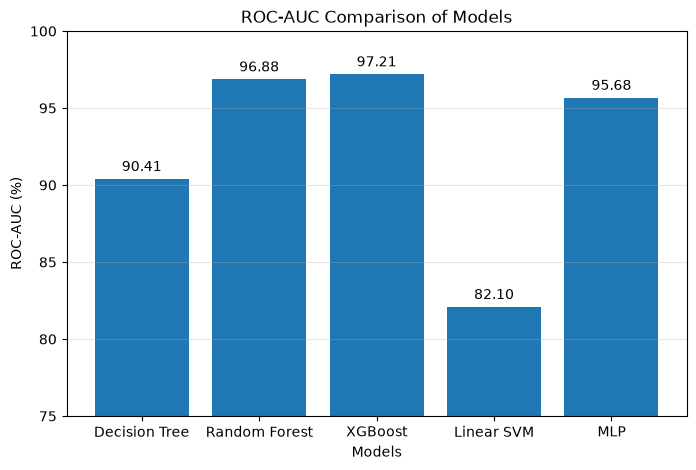

In [67]:
plt.figure(figsize=(8,5))

plt.bar(comparison_df["Model"],
        comparison_df["ROC-AUC"])

plt.title("ROC-AUC Comparison of Models")
plt.xlabel("Models")
plt.ylabel("ROC-AUC (%)")

for i, value in enumerate(comparison_df["ROC-AUC"]):
    plt.text(i, value+0.5, f"{value:.2f}", ha='center')

plt.ylim(75,100)

plt.grid(axis='y', alpha=0.3)

plt.show()

### ROC-AUC Comparison Observation

XGBoost achieved the highest ROC-AUC score (97.21%), demonstrating the strongest ability to distinguish between deteriorating and non-deteriorating patients across different classification thresholds. Random Forest and MLP also exhibited excellent discriminative performance, while Linear SVM achieved the lowest ROC-AUC score.

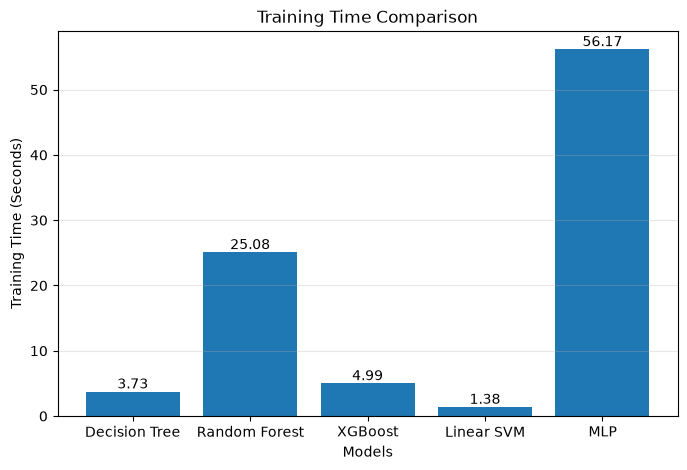

In [68]:
plt.figure(figsize=(8,5))

plt.bar(comparison_df["Model"],
        comparison_df["Training Time (sec)"])

plt.title("Training Time Comparison")
plt.xlabel("Models")
plt.ylabel("Training Time (Seconds)")

for i, value in enumerate(comparison_df["Training Time (sec)"]):
    plt.text(i, value+0.5, f"{value:.2f}", ha='center')

plt.grid(axis='y', alpha=0.3)

plt.show()

### Training Time Comparison Observation

Linear SVM required the least training time, followed by Decision Tree and XGBoost. Random Forest required moderate training time due to the construction of multiple decision trees, while the MLP required the longest training time because of iterative optimization over multiple epochs.

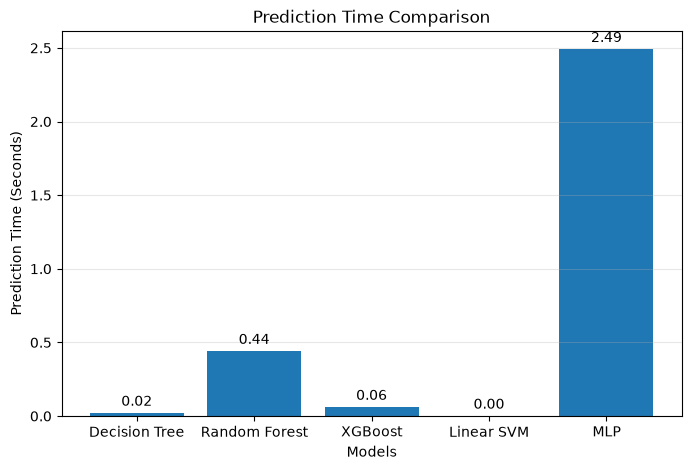

In [69]:
plt.figure(figsize=(8,5))

plt.bar(comparison_df["Model"],
        comparison_df["Prediction Time (sec)"])

plt.title("Prediction Time Comparison")
plt.xlabel("Models")
plt.ylabel("Prediction Time (Seconds)")

for i, value in enumerate(comparison_df["Prediction Time (sec)"]):
    plt.text(i, value+0.05, f"{value:.2f}", ha='center')

plt.grid(axis='y', alpha=0.3)

plt.show()

### Prediction Time Comparison Observation

Decision Tree and Linear SVM produced predictions almost instantaneously, making them suitable for real-time inference. XGBoost also achieved very fast prediction times. Although MLP delivered the highest accuracy, it required the longest prediction time among the evaluated models.

# ROC Curve Comparison of All Models

To compare the classification performance of all machine learning models, a combined Receiver Operating Characteristic (ROC) curve is plotted.

The ROC curve illustrates the trade-off between the True Positive Rate (Sensitivity) and the False Positive Rate across different decision thresholds. The Area Under the ROC Curve (ROC-AUC) provides an overall measure of a model's ability to distinguish between patients who are likely to deteriorate and those who are not.

A higher ROC-AUC value indicates better discriminative performance. This visualization enables a direct comparison of the predictive capabilities of Decision Tree, Random Forest, XGBoost, Linear SVM, and Multi-Layer Perceptron (MLP) models.

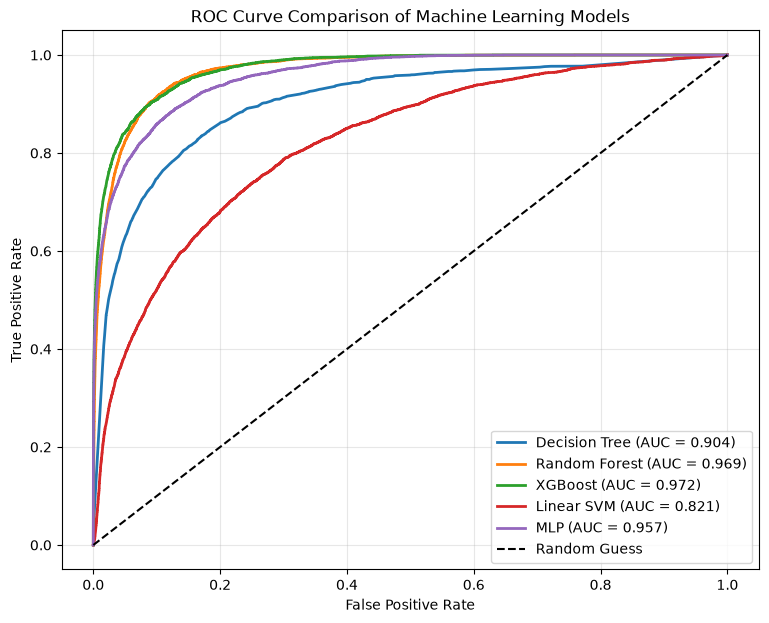

In [85]:
plt.figure(figsize=(9,7))

plt.plot(dt_fpr, dt_tpr,
         linewidth=2,
         label=f"Decision Tree (AUC = {dt_auc:.3f})")

plt.plot(rf_fpr, rf_tpr,
         linewidth=2,
         label=f"Random Forest (AUC = {rf_auc:.3f})")

plt.plot(xgb_fpr, xgb_tpr,
         linewidth=2,
         label=f"XGBoost (AUC = {xgb_auc:.3f})")

plt.plot(svm_fpr, svm_tpr,
         linewidth=2,
         label=f"Linear SVM (AUC = {svm_auc:.3f})")

plt.plot(mlp_fpr, mlp_tpr,
         linewidth=2,
         label=f"MLP (AUC = {mlp_auc:.3f})")

plt.plot([0,1],[0,1],'k--',label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison of Machine Learning Models")

plt.legend(loc="lower right")

plt.grid(alpha=0.3)

plt.show()

### ROC Curve Comparison Observation

The combined ROC curve demonstrates that all five machine learning models perform better than random guessing, as each ROC curve lies well above the diagonal reference line.

Among all the evaluated models, **XGBoost achieved the highest ROC-AUC score of 0.972**, indicating the strongest ability to distinguish between deteriorating and non-deteriorating ICU patients. **Random Forest closely followed with a ROC-AUC of 0.969**, showing comparable predictive performance and excellent class discrimination.

The **Multi-Layer Perceptron (MLP)** achieved a **ROC-AUC of 0.957**, indicating strong predictive capability while maintaining the highest overall classification accuracy. The **Decision Tree** classifier obtained a **ROC-AUC of 0.904**, demonstrating satisfactory performance but lower discriminative ability compared to the ensemble methods.

The **Linear SVM** recorded the lowest ROC-AUC score (**0.821**), suggesting that a linear decision boundary is insufficient to capture the complex, non-linear relationships present in the ICU patient data.

Overall, the ROC comparison confirms that **ensemble learning algorithms (XGBoost and Random Forest)** provide the most reliable performance for ICU patient deterioration prediction. While Random Forest offers a strong balance between precision and recall, XGBoost exhibits the best overall discriminative capability, making it one of the most suitable models for this healthcare prediction task.

# Model Performance Comparison

To identify the most suitable model for ICU patient deterioration prediction, the performance metrics of all trained machine learning models are compared.

The comparison includes Accuracy, Precision, Recall, F1-Score, ROC-AUC, Training Time, and Prediction Time. These evaluation metrics provide a comprehensive assessment of each model's predictive capability, computational efficiency, and suitability for healthcare applications.

Since this is a medical prediction problem with an imbalanced dataset, metrics such as Recall, F1-Score, and ROC-AUC are considered more informative than Accuracy alone.

In [114]:
# Create Performance Comparison Table

comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.round(4)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time (sec),Prediction Time (sec)
0,Decision Tree,82.99,21.87,83.44,34.66,90.41,3.73,0.02
1,Random Forest,94.33,48.56,82.36,61.10,96.88,25.08,0.44
2,XGBoost,91.65,38.31,89.35,53.63,97.21,4.99,0.06
3,Linear SVM,75.92,14.80,72.62,24.59,82.10,1.38,0.00
4,MLP,96.87,85.62,50.60,63.61,95.68,56.17,2.49


### Model Performance Comparison Observation

The performance comparison table summarizes the predictive performance and computational efficiency of all five machine learning models evaluated for ICU patient deterioration prediction.

Among all the models, the **Multi-Layer Perceptron (MLP)** achieved the highest **Accuracy (96.87%)**, **Precision (85.62%)**, and **F1-Score (63.61%)**, indicating excellent overall classification performance and the lowest number of false positive predictions. However, it required the longest training time (**56.17 seconds**) and prediction time (**2.49 seconds**).

The **XGBoost** classifier achieved the highest **ROC-AUC (97.21%)** and **Recall (89.35%)**, demonstrating the strongest ability to correctly identify patients at risk of deterioration while maintaining excellent discrimination between classes. In healthcare applications, high recall is particularly important because missing a deteriorating patient may have serious clinical consequences.

The **Random Forest** classifier also delivered strong performance, achieving **94.33% accuracy**, **96.88% ROC-AUC**, and a balanced **F1-score of 61.10%**. It provided a good trade-off between predictive performance and computational efficiency.

The **Decision Tree** classifier produced satisfactory recall (**83.44%**) but lower precision (**21.87%**), resulting in a large number of false positive predictions. Although highly interpretable, its overall predictive performance was lower than the ensemble learning models.

The **Linear SVM** showed the weakest overall performance, achieving the lowest values for Accuracy (**75.92%**), Precision (**14.80%**), F1-score (**24.59%**), and ROC-AUC (**82.10%**). This suggests that a linear decision boundary is insufficient to model the complex relationships present in the clinical dataset.

Overall, **XGBoost**, **Random Forest**, and **MLP** demonstrated superior performance compared with Decision Tree and Linear SVM. Considering the clinical importance of correctly identifying deteriorating patients, **XGBoost emerged as the most suitable model** due to its excellent balance between Recall, ROC-AUC, computational efficiency, and overall predictive capability.

# Best Model Selection

Selecting the most appropriate model for ICU patient deterioration prediction requires considering multiple evaluation metrics rather than relying solely on accuracy.

In healthcare applications, the primary objective is to correctly identify patients who are at risk of deterioration. Therefore, metrics such as Recall, F1-Score, and ROC-AUC are more informative than Accuracy alone. Computational efficiency is also considered, particularly for real-time clinical decision support systems.

In [115]:
# Display Best Model Based on ROC-AUC

best_model = comparison_df.loc[
    comparison_df["ROC-AUC"].idxmax()
]

print("Best Performing Model\n")

print(best_model)

Best Performing Model

Model                    XGBoost
Accuracy                   91.65
Precision                  38.31
Recall                     89.35
F1 Score                   53.63
ROC-AUC                    97.21
Training Time (sec)         4.99
Prediction Time (sec)       0.06
Name: 2, dtype: object


### Best Model Selection Observation

Based on the evaluation results, **XGBoost** was selected as the best-performing model for ICU patient deterioration prediction.

Although the Multi-Layer Perceptron (MLP) achieved the highest Accuracy and Precision, its Recall was considerably lower than XGBoost, indicating that it failed to identify a larger proportion of deteriorating patients.

XGBoost achieved the highest ROC-AUC (**97.21%**) and the highest Recall (**89.35%**) while maintaining competitive Accuracy (**91.65%**) and a relatively short training time (**4.99 seconds**). This combination makes it highly effective at distinguishing between deteriorating and non-deteriorating patients.

In medical diagnosis, minimizing false negatives is often more critical than maximizing overall accuracy. Therefore, the higher Recall achieved by XGBoost is a significant advantage because it reduces the likelihood of missing patients who require timely clinical intervention.

Considering predictive performance, class discrimination, computational efficiency, and clinical relevance, **XGBoost is identified as the most suitable model for this ICU patient deterioration prediction task.**

# Conclusion

This project focused on predicting ICU patient deterioration using machine learning techniques based on physiological measurements and clinical data. After data preprocessing, feature encoding, train-test splitting, and feature scaling, five different models were developed and evaluated: Decision Tree, Random Forest, XGBoost, Linear SVM, and Multi-Layer Perceptron (MLP).

Each model was evaluated using Accuracy, Precision, Recall, F1-Score, ROC-AUC, Training Time, and Prediction Time to provide a comprehensive comparison of predictive performance.

Among the evaluated models, the MLP achieved the highest Accuracy (96.87%) and Precision (85.62%), while XGBoost achieved the highest Recall (89.35%) and ROC-AUC (97.21%). Random Forest also demonstrated excellent overall performance by providing a balanced trade-off between Accuracy, Precision, Recall, and computational efficiency.

Considering the clinical objective of minimizing missed deterioration events, XGBoost was selected as the most suitable model for ICU patient deterioration prediction. Its ability to correctly identify a larger proportion of high-risk patients makes it particularly valuable for healthcare decision support systems, where early detection can significantly improve patient outcomes.

Overall, this study demonstrates that ensemble learning techniques, particularly XGBoost and Random Forest, are highly effective for ICU patient deterioration prediction and can support clinicians in identifying patients who require timely medical intervention.

# Future Scope

Although the developed models achieved strong predictive performance, several improvements can further enhance the effectiveness and practical applicability of the system.

- Incorporate real-time physiological monitoring data collected directly from ICU monitoring systems to enable continuous patient risk assessment.
- Perform hyperparameter optimization using techniques such as Grid Search, Random Search, or Bayesian Optimization to further improve model performance.
- Validate the trained models using external datasets from multiple hospitals to evaluate their generalization capability.
- Extend the system by incorporating sequential physiological data and time-series models when continuous patient monitoring data becomes available.
- Develop a web-based or mobile clinical decision support system that enables healthcare professionals to obtain real-time deterioration risk predictions.
- Improve model interpretability using Explainable AI (XAI) techniques such as SHAP and LIME to provide transparent explanations for each prediction.
- Integrate additional clinical information, including laboratory reports, medication history, imaging findings, and electronic health records, to improve prediction accuracy and support comprehensive clinical decision-making.